In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load the dataset
df = pd.read_csv("student-mat.csv", sep=";")

# Display the first few rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
# Check the size of the dataset
print("Shape of dataset:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Inspect variable types
print("Variable types:")
print(df.dtypes)

# Define target and predictors
y = df["G3"]
X = df.drop(columns=["G3", "G1", "G2"])
print(X.head())
print("Target variable:", y.name)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Shape of dataset: (395, 33)
Number of rows: 395
Number of columns: 33
Variable types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T    

In [4]:
# List of categorical variables given in the brief
categorical_cols = [
    "school", "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob",
    "reason", "guardian", "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)
print(X_encoded.head())

Shape before encoding: (395, 30)
Shape after encoding: (395, 56)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  activities_no  activities_yes  nursery_no  nursery_yes  \
0     1  ...           True           False       False         True   
1     1  ...           True           False        True        False   
2     2  ...           True           False       False         True   
3     1  ...          False            True       False         True   
4     1  ...           True           False       False         True   

   higher_no  higher_

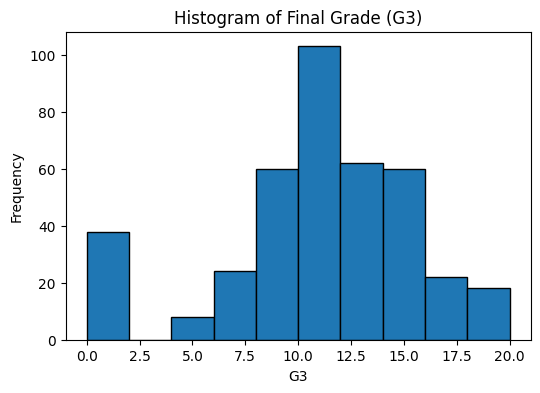

In [5]:
# Summary statistics for numeric variables
df.describe()

plt.figure(figsize=(6, 4))
plt.hist(df["G3"], bins=10, edgecolor="black")
plt.title("Histogram of Final Grade (G3)")
plt.xlabel("G3")
plt.ylabel("Frequency")
plt.show()

This histogram shows the distribution of the final grade G3. Most students’ grades are concentrated in the middle range, especially around 8 to 15, suggesting that most final grades are moderate rather than extremely low or extremely high. There are fewer students at the two ends of the scale, although the plot also shows that some students have G3=0. Overall, the distribution of G3 is not uniform and is mainly concentrated in the middle score range.

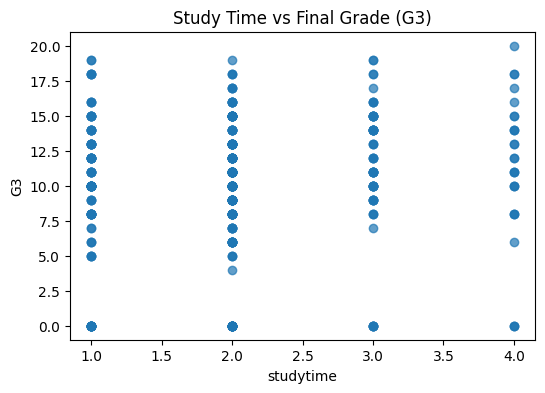

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(df["studytime"], df["G3"], alpha=0.7)
plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("studytime")
plt.ylabel("G3")
plt.show()

This scatter plot shows the relationship between studytime and G3. Since studytime is a discrete variable, the points appear in vertical columns. The plot suggests that higher study time levels may be associated with more high grades, for example at studytime = 3 or 4, where more larger G3 values can be seen. However, the relationship is not perfectly clear, because there is still considerable variation in grades within each study time category. This suggests that studytime may be related to final performance, but it does not determine the grade on its own.

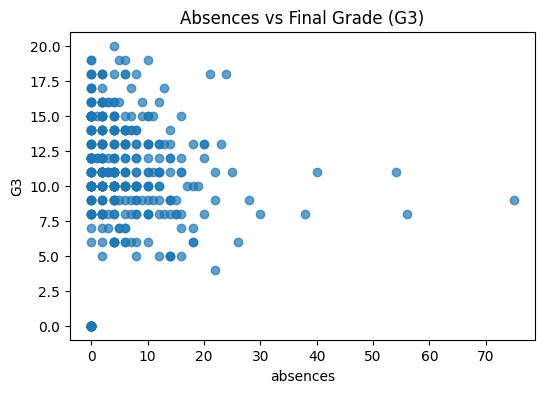

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(df["absences"], df["G3"], alpha=0.7)
plt.title("Absences vs Final Grade (G3)")
plt.xlabel("absences")
plt.ylabel("G3")
plt.show()

This scatter plot shows the relationship between absences and G3. Most students have relatively low numbers of absences, with observations concentrated near the lower end of the x-axis, while grades remain spread across a wide range. The plot suggests that as absences increase, high grades may become less common, indicating a possible negative association between absences and final grade. However, this trend is not very strong, because there is still substantial variation in grades among students with low absence levels, and there are relatively few observations at very high absence levels. Therefore, the plot only suggests that absences may have some influence on performance, rather than showing a clear deterministic relationship.

The histogram of G3 shows that most final grades are concentrated in the middle range, with relatively few extreme values, although some students have a grade of 0. The scatter plot of studytime against G3 suggests a possible positive association, since higher study time levels appear to include more higher grades, but the relationship is not strong. The scatter plot of absences against G3 suggests a possible negative association, as high grades seem less common when absences are larger, although the pattern is still fairly dispersed. Overall, these plots indicate that the predictors may contain useful information, but the relationships are not perfectly simple or linear.

In [8]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression")
print("MAE :", round(mae_lin, 3))
print("RMSE:", round(rmse_lin, 3))
print("Intercept:", round(lin_model.intercept_, 3))
print("Number of coefficients:", len(lin_model.coef_))

X_train shape: (316, 56)
X_test shape: (79, 56)
y_train shape: (316,)
y_test shape: (79,)
Linear Regression
MAE : 3.395
RMSE: 4.196
Intercept: 14.775
Number of coefficients: 56


/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


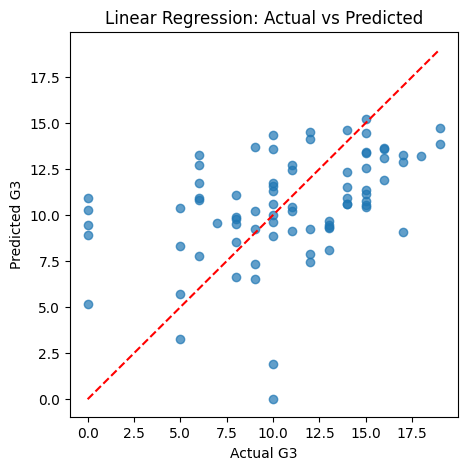

In [9]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_lin, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.show()

The plot shows that linear regression captures the overall trend, but the predictions are clearly compressed toward the middle range: very low actual grades, such as G3=0, are overestimated, while high actual grades are underestimated. One possible reason is that student performance is influenced by multiple interacting factors, whereas linear regression assumes a single global linear relationship between the features and G3 and applies the same fixed linear weights to all samples, making it difficult to capture more complex nonlinear patterns.  

In [10]:
# Standard scaling for k-NN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("k-NN Regressor")
print("MAE :", round(mae_knn, 3))
print("RMSE:", round(rmse_knn, 3))

Scaled training data shape: (316, 56)
Scaled test data shape: (79, 56)
k-NN Regressor
MAE : 3.754
RMSE: 4.621


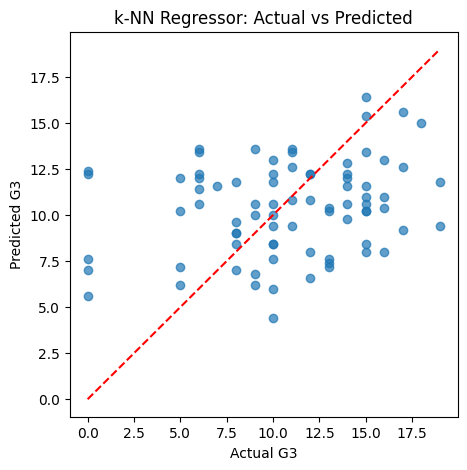

In [11]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_knn, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.title("k-NN Regressor: Actual vs Predicted")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.show()

The k-NN plot shows an overall positive trend, but predictions remain quite scattered. Very low grades are often overestimated — most notably for students with G3 = 0, whose nearest neighbours in feature space are predominantly mid-range students — while grades above approximately 12.5 tend to be underestimated. A possible reason is that k-NN predicts by averaging the grades of nearby samples, so extreme values are pulled toward the denser middle region of the dataset. This makes the model less sensitive to unusually low or high outcomes, and better suited to interpolation within a dense distribution than to capturing the full range of G3.

In [12]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print("Decision Tree Regressor")
print("MAE :", round(mae_tree, 3))
print("RMSE:", round(rmse_tree, 3))

Decision Tree Regressor
MAE : 3.536
RMSE: 4.621


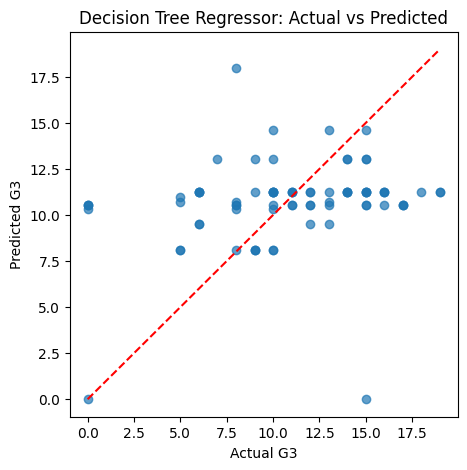

In [13]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred_tree, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.title("Decision Tree Regressor: Actual vs Predicted")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.show()

The Decision Tree plot shows a positive trend overall, but predictions are clustered at discrete horizontal levels, reflecting the fact that all samples within a leaf node receive the same predicted value. While the model correctly predicts near-zero grades for some low-achieving students — an improvement over k-NN — a severe outlier is visible where a student with Actual G3 ≈ 15 is predicted as 0, suggesting the tree has learned an overly specific splitting rule that misclassifies this case. High grades above 15 remain consistently underestimated, as the training data contains too few such examples to form a reliable leaf.

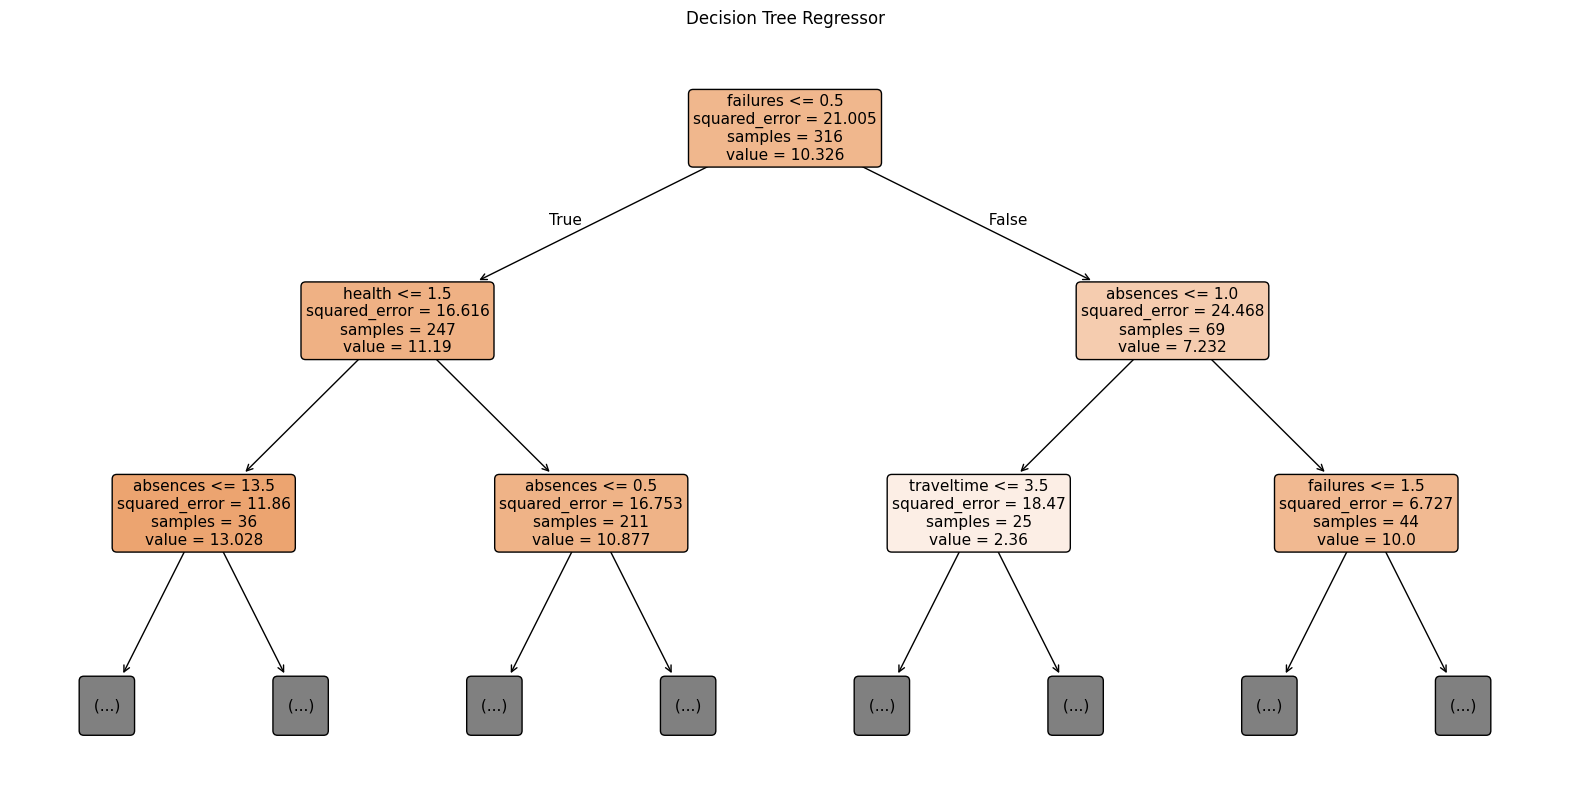

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=2
)
plt.title("Decision Tree Regressor")
plt.show()

In [15]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "k-NN Regressor", "Decision Tree Regressor"],
    "MAE": [mae_lin, mae_knn, mae_tree],
    "RMSE": [rmse_lin, rmse_knn, rmse_tree]
})

results

,Model,MAE,RMSE
0,Linear Regression,3.395261,4.195681
1,k-NN Regressor,3.754430,4.620538
2,Decision Tree Regressor,3.535835,4.621128


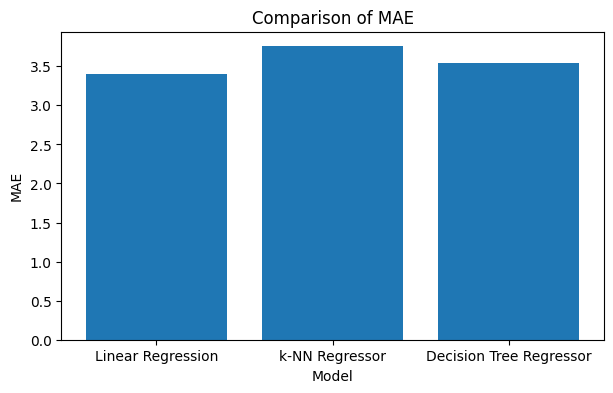

In [16]:
plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["MAE"])
plt.title("Comparison of MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

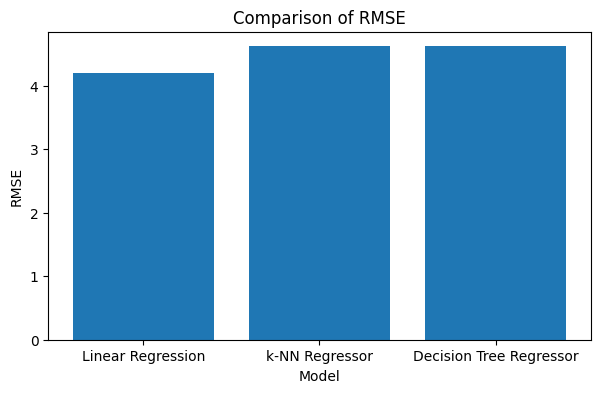

In [17]:
plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["RMSE"])
plt.title("Comparison of RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

Across both metrics, Linear Regression achieves the lowest MAE (about 3.4) and RMSE (about 4.2), suggesting that it captures the underlying trend in G3 more effectively than the other two models. k-NN and Decision Tree perform similarly, with RMSE values close to 4.6, indicating comparable sensitivity to larger prediction errors. The consistent gap between RMSE and MAE across all models suggests the presence of some observations with relatively large errors, possibly including the students with G3 = 0, which inflate squared error more strongly.

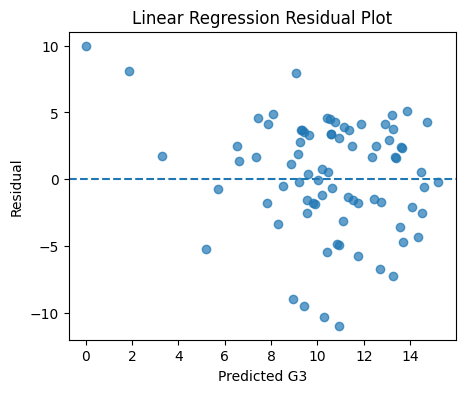

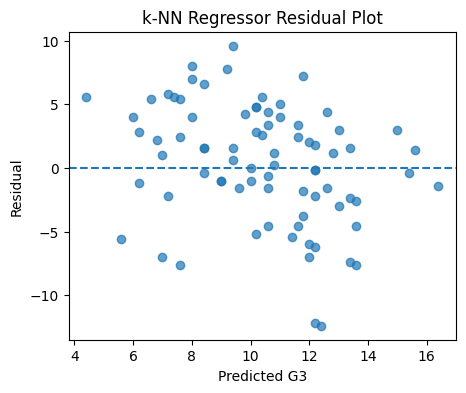

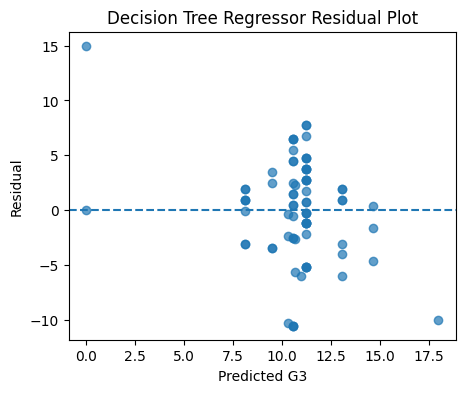

In [18]:
# Residuals
res_lin = y_test - y_pred_lin
res_knn = y_test - y_pred_knn
res_tree = y_test - y_pred_tree

# Linear Regression residual plot
plt.figure(figsize=(5, 4))
plt.scatter(y_pred_lin, res_lin, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Linear Regression Residual Plot")
plt.xlabel("Predicted G3")
plt.ylabel("Residual")
plt.show()

# k-NN residual plot
plt.figure(figsize=(5, 4))
plt.scatter(y_pred_knn, res_knn, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("k-NN Regressor Residual Plot")
plt.xlabel("Predicted G3")
plt.ylabel("Residual")
plt.show()

# Decision Tree residual plot
plt.figure(figsize=(5, 4))
plt.scatter(y_pred_tree, res_tree, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Decision Tree Regressor Residual Plot")
plt.xlabel("Predicted G3")
plt.ylabel("Residual")
plt.show()

The residual plots provide further evidence for the model comparison. Linear Regression shows residuals that are relatively more balanced around zero, although several large errors are still present. This suggests that it captures the overall structure of the data more consistently than the other two models. In contrast, the k-NN residuals are more widely dispersed, indicating less stable prediction errors. The Decision Tree residuals are concentrated around a few predicted values, reflecting the fact that tree-based regression produces piecewise constant predictions, while still showing some large positive and negative errors. Overall, the residual plots support the earlier conclusion from MAE and RMSE that Linear Regression performs best, while k-NN and Decision Tree are both less accurate on this dataset.